<a href="https://colab.research.google.com/github/deboratech/tcc_usp_esalq/blob/main/codigo_completo_tcc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =========================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# =========================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================
# 2. CARREGAMENTO DAS BASES
# =========================================

In [2]:
ga4 = pd.read_csv('ga4_blackfriday_multiplataforma_2024_2025.csv')
google = pd.read_csv('google_ads_blackfriday_2024_2025.csv')
meta = pd.read_csv('meta_ads_blackfriday_2024_2025.csv')
tiktok = pd.read_csv('tiktok_ads_blackfriday_2024_2025.csv')

# =========================================
# 3. PADRONIZAÇÃO E TRATAMENTO
# =========================================

In [3]:
# Conversão de datas
for df_temp in [ga4, google, meta, tiktok]:
    df_temp['data'] = pd.to_datetime(df_temp['data'])

In [4]:
# Padronizar nomes
ga4.rename(columns={'campanha_sessao': 'campanha'}, inplace=True)

# =========================================
# 4. CONCATENAR BASES DE MÍDIA
# =========================================

In [5]:
google['canal'] = 'Google'
meta['canal'] = 'Meta'
tiktok['canal'] = 'TikTok'

midia = pd.concat([google, meta, tiktok], ignore_index=True)

# =========================================
# 5. MERGE (DATA + CAMPANHA + ANO)
# =========================================


In [6]:
df = pd.merge(
    ga4,
    midia,
    on=['data', 'campanha', 'ano'],
    how='left'
)

# =========================================
# 6. VALIDAÇÃO DA UNIÃO
# =========================================

In [7]:
print("\n===== BASE UNIFICADA =====")
print(df.head())


===== BASE UNIFICADA =====
    ano       data                                campanha  sessoes  \
0  2024 2024-11-01  tt_ads_top_blackfriday_video_awareness     4966   
1  2024 2024-11-01  tt_ads_top_blackfriday_video_discovery     2696   
2  2024 2024-11-01     tt_ads_top_blackfriday_video_oferta     3760   
3  2024 2024-11-01    meta_ads_mid_blackfriday_retargeting     2103   
4  2024 2024-11-01    meta_ads_mid_blackfriday_engajamento     1026   

   transacoes  receita origem_midia_sessao  plataforma funil  impressoes  \
0          17  2828.56        tiktok / cpc  TikTok Ads  Topo      141370   
1          17  2089.35        tiktok / cpc  TikTok Ads  Topo      173786   
2          29  5776.05        tiktok / cpc  TikTok Ads  Topo       97814   
3           5   990.22          meta / cpc    Meta Ads  Meio       84213   
4          22  4358.72          meta / cpc    Meta Ads  Meio       37401   

   cliques    custo   canal  
0     2369  1559.06  TikTok  
1     2190  1512.27  TikTok 

In [8]:
print("\nDimensão da base:")
print(df.shape)


Dimensão da base:
(540, 13)


In [9]:
print("\nColunas disponíveis:")
print(df.columns)


Colunas disponíveis:
Index(['ano', 'data', 'campanha', 'sessoes', 'transacoes', 'receita',
       'origem_midia_sessao', 'plataforma', 'funil', 'impressoes', 'cliques',
       'custo', 'canal'],
      dtype='object')


In [10]:
print("\nValores nulos por coluna:")
print(df.isnull().sum())


Valores nulos por coluna:
ano                    0
data                   0
campanha               0
sessoes                0
transacoes             0
receita                0
origem_midia_sessao    0
plataforma             0
funil                  0
impressoes             0
cliques                0
custo                  0
canal                  0
dtype: int64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ano                  540 non-null    int64         
 1   data                 540 non-null    datetime64[ns]
 2   campanha             540 non-null    object        
 3   sessoes              540 non-null    int64         
 4   transacoes           540 non-null    int64         
 5   receita              540 non-null    float64       
 6   origem_midia_sessao  540 non-null    object        
 7   plataforma           540 non-null    object        
 8   funil                540 non-null    object        
 9   impressoes           540 non-null    int64         
 10  cliques              540 non-null    int64         
 11  custo                540 non-null    float64       
 12  canal                540 non-null    object        
dtypes: datetime64[ns](1), float64(2), i

In [12]:
df.to_csv('base_unificada.csv', index=False)

In [13]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
535,False
536,False
537,False
538,False


In [14]:
df.describe()

,ano,data,sessoes,transacoes,receita,impressoes,cliques,custo
count,540.000000,540,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000
mean,2024.500000,2025-05-17 00:00:00,2734.520370,34.274074,7886.676037,100021.225926,1911.868519,2693.365685
min,2024.000000,2024-11-01 00:00:00,227.000000,1.000000,161.650000,8796.000000,252.000000,197.320000
25%,2024.000000,2024-11-15 18:00:00,1408.500000,14.000000,2562.492500,47786.000000,1119.500000,1104.230000
50%,2024.500000,2025-05-17 00:00:00,2412.000000,27.000000,5134.125000,81987.000000,1681.000000,1843.110000
75%,2025.000000,2025-11-15 06:00:00,3730.000000,43.000000,9715.477500,140928.250000,2582.250000,3218.952500
max,2025.000000,2025-11-30 00:00:00,9290.000000,176.000000,61080.180000,299701.000000,5377.000000,16474.660000
std,0.500464,NaN,1754.163717,28.182661,8381.982042,68155.256273,1054.694159,2488.038270



# =========================================
# 8. KPI POR CANAL
# =========================================

In [15]:
kpi = df.groupby('canal').agg({
    'custo': 'sum',
    'sessoes': 'sum',
    'transacoes': 'sum',
    'receita': 'sum'
}).reset_index()

kpi['conv_rate'] = kpi['transacoes'] / kpi['sessoes'] * 100
kpi['tkm'] = kpi['receita'] / kpi['transacoes']
kpi['roi'] = kpi['receita'] / kpi['custo']

print("\n===== KPI POR CANAL =====")
display(kpi)


===== KPI POR CANAL =====


,canal,custo,sessoes,transacoes,receita,conv_rate,tkm,roi
0,Google,798343.47,304982,8547,2386401.13,2.802460,279.209211,2.989191
1,Meta,415509.52,499959,5957,1241497.94,1.191498,208.409928,2.987893
2,TikTok,240564.48,671700,4004,630905.99,0.596099,157.568929,2.622607



# =========================================
# 9. ANÁLISE EXPLORATÓRIA POR CANAL
# =========================================

Shape df_plot: (180, 7)
Canais: ['Google' 'Meta' 'TikTok']
Anos: [2024 2025]


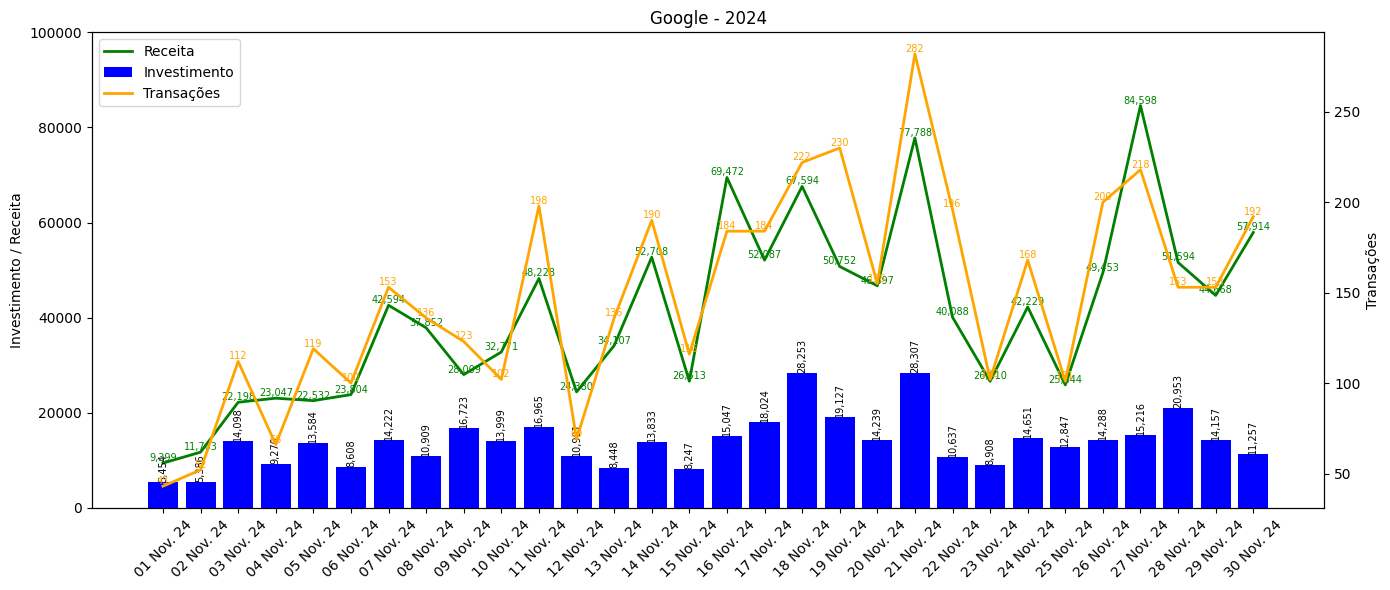

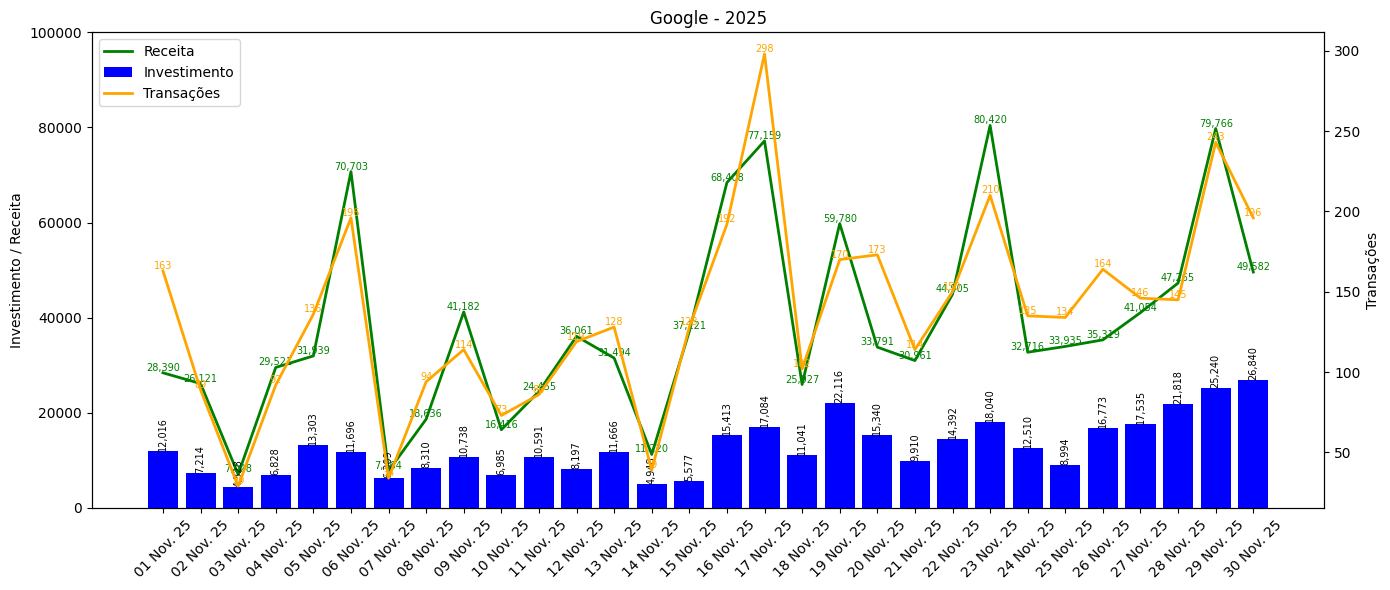

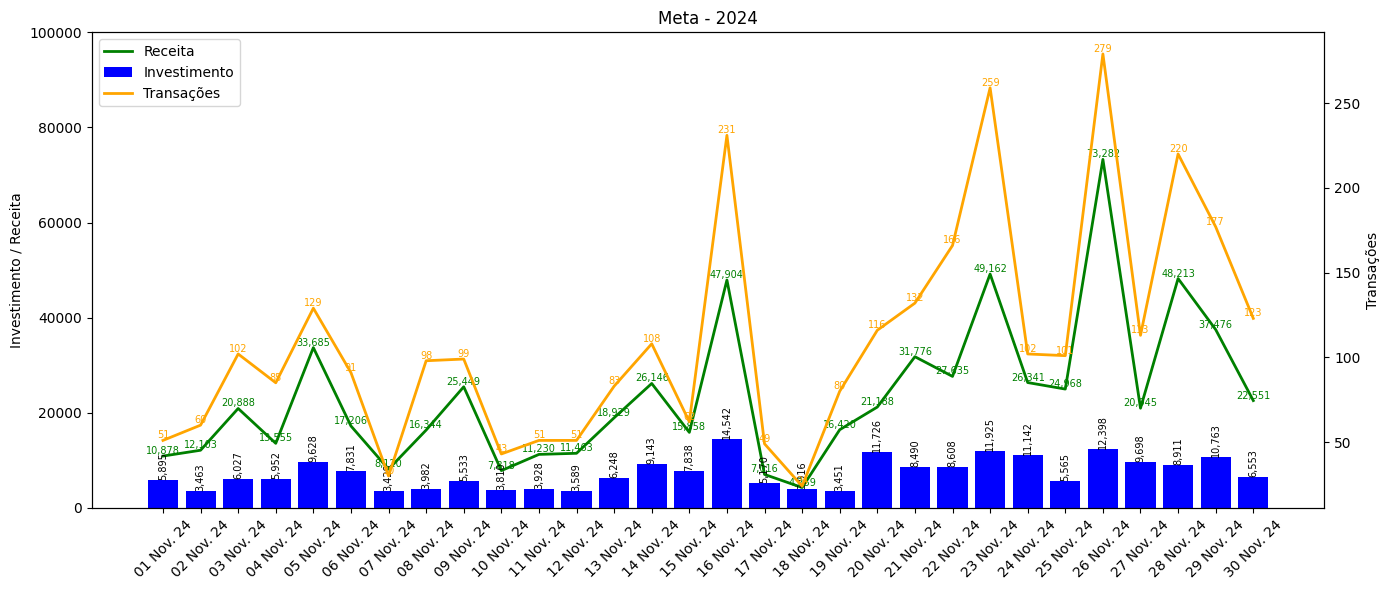

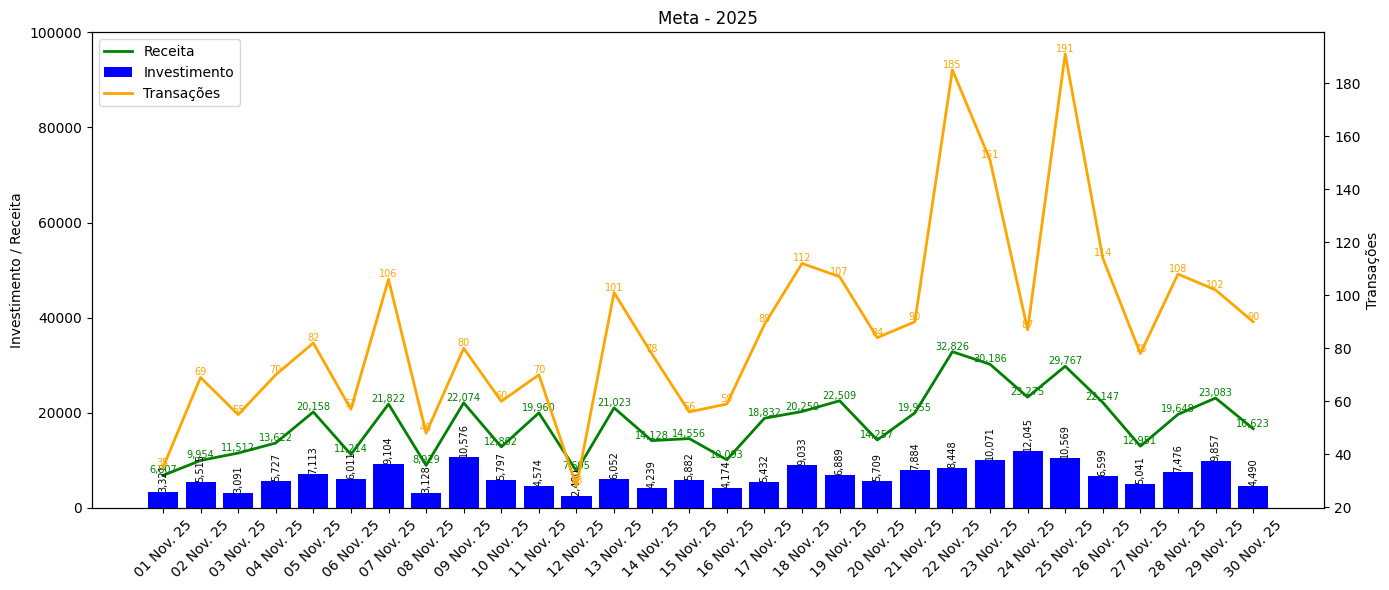

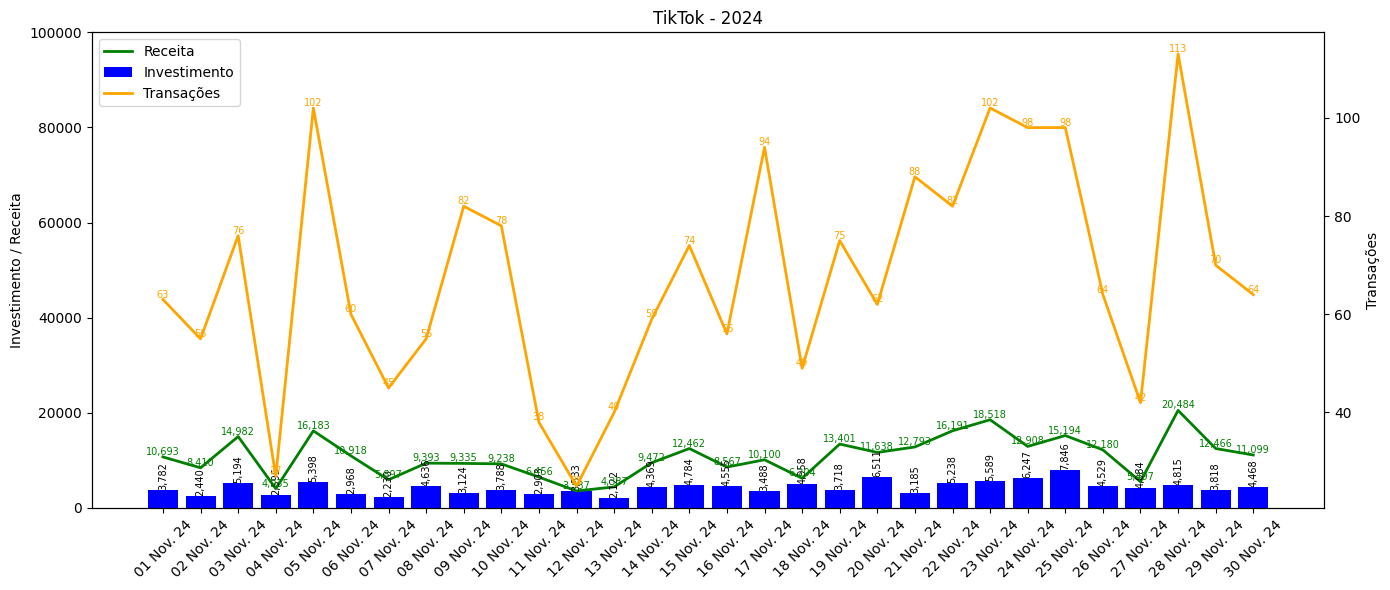

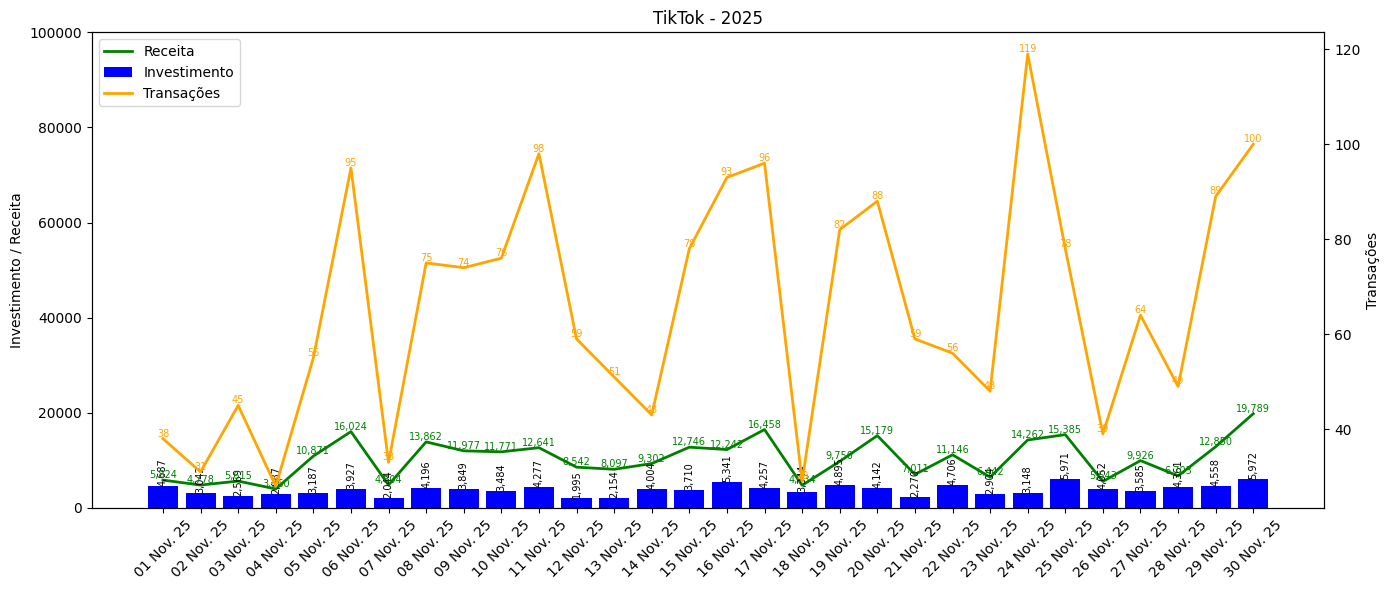

In [16]:
# =========================================
# 2. PREPARAÇÃO DOS DADOS
# =========================================

# Garantir que data está correta
df['data'] = pd.to_datetime(df['data'])

# Criar ano
df['ano'] = df['data'].dt.year

# Ordenar
df = df.sort_values('data')

# Criar label de data
df['data_formatada'] = df['data'].dt.strftime('%d %b. %y')

# Base agregada
df_plot = df.groupby(['canal', 'ano', 'data', 'data_formatada']).agg({
    'custo': 'sum',
    'transacoes': 'sum',
    'receita': 'sum'
}).reset_index()

# =========================================
# 3. VALIDAÇÃO (IMPORTANTE)
# =========================================
print("Shape df_plot:", df_plot.shape)
print("Canais:", df_plot['canal'].unique())
print("Anos:", df_plot['ano'].unique())

# =========================================
# 4. FUNÇÃO DE GRÁFICO
# =========================================

def plot_dashboard(canal, ano):
    temp = df_plot[
        (df_plot['canal'] == canal) &
        (df_plot['ano'] == ano)
    ].sort_values('data')

    # Se estiver vazio, avisar
    if temp.empty:
        print(f"Sem dados para {canal} - {ano}")
        return

    fig, ax1 = plt.subplots(figsize=(14,6))

    x = range(len(temp))

    # 🔵 INVESTIMENTO (barra)
    bars = ax1.bar(x, temp['custo'], color='blue', label='Investimento')

    # 🟢 RECEITA (linha)
    ax1.plot(x, temp['receita'], color='green', linewidth=2, label='Receita')

    ax1.set_ylabel('Investimento / Receita')
    ax1.set_ylim(0, 100000)

    # 🟠 TRANSAÇÕES (eixo direito)
    ax2 = ax1.twinx()
    ax2.plot(x, temp['transacoes'], color='orange', linewidth=2, label='Transações')
    ax2.set_ylabel('Transações')

    # 🔢 RÓTULOS INVESTIMENTO
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=7,
            rotation=90
        )

    # 🔢 RÓTULOS RECEITA
    for i, val in enumerate(temp['receita']):
        ax1.text(
            i,
            val,
            f'{int(val):,}',
            ha='center',
            va='bottom',
            fontsize=7,
            color='green'
        )

    # 🔢 RÓTULOS TRANSAÇÕES
    for i, val in enumerate(temp['transacoes']):
        ax2.text(
            i,
            val,
            int(val),
            ha='center',
            va='bottom',
            fontsize=7,
            color='orange'
        )

    # Eixo X
    ax1.set_xticks(x)
    ax1.set_xticklabels(temp['data_formatada'], rotation=45)

    # Legenda
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    # Título
    plt.title(f'{canal} - {ano}')

    plt.tight_layout()
    plt.show()

# =========================================
# 6. GERAR TODOS OS GRÁFICOS
# =========================================
for canal in df_plot['canal'].unique():
    for ano in [2024, 2025]:
        plot_dashboard(canal, ano)


# =========================================
# 10. FUNIL POR CANAL
# =========================================

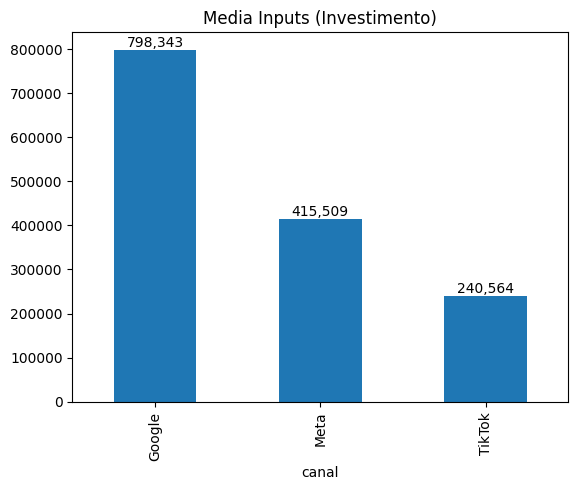

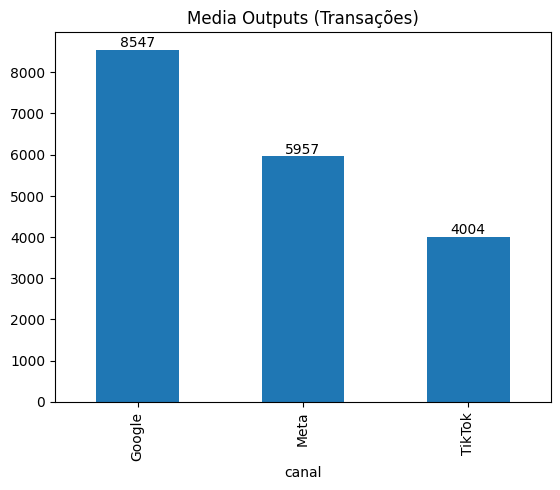

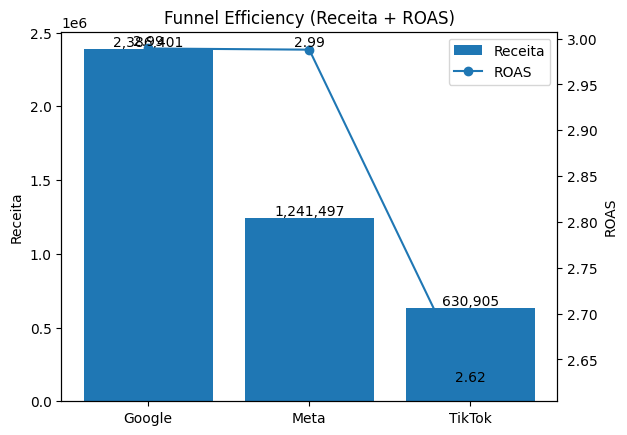

In [17]:
# =========================================
# FUNIL POR CANAL
# =========================================

funil = df.groupby('canal').agg({
    'custo': 'sum',
    'transacoes': 'sum',
    'receita': 'sum'
}).reset_index()

# Calcular ROAS
funil['roas'] = funil['receita'] / funil['custo']

# =========================================
# 1. INVESTIMENTO (MEDIA INPUTS)
# =========================================

ax = funil.plot(kind='bar', x='canal', y='custo', legend=False, title='Media Inputs (Investimento)')

# Rótulos
for i, val in enumerate(funil['custo']):
    ax.text(i, val, f'{int(val):,}', ha='center', va='bottom')

plt.show()

# =========================================
# 2. TRANSAÇÕES (MEDIA OUTPUTS)
# =========================================

ax = funil.plot(kind='bar', x='canal', y='transacoes', legend=False, title='Media Outputs (Transações)')

# Rótulos
for i, val in enumerate(funil['transacoes']):
    ax.text(i, val, int(val), ha='center', va='bottom')

plt.show()

# =========================================
# 3. RECEITA + ROAS
# =========================================

fig, ax1 = plt.subplots()

# 🔵 RECEITA (barra)
ax1.bar(funil['canal'], funil['receita'], label='Receita')
ax1.set_ylabel('Receita')

# Rótulos receita
for i, val in enumerate(funil['receita']):
    ax1.text(i, val, f'{int(val):,}', ha='center', va='bottom')

# 🟠 ROAS (linha)
ax2 = ax1.twinx()
ax2.plot(funil['canal'], funil['roas'], marker='o', label='ROAS')
ax2.set_ylabel('ROAS')

# Rótulos ROAS
for i, val in enumerate(funil['roas']):
    ax2.text(i, val, f'{val:.2f}', ha='center', va='bottom')

# Título
plt.title('Funnel Efficiency (Receita + ROAS)')

# Legenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.show()

# =====================================================
# 2. MODELO PREDITIVO (REGRESSÃO) E AVALIAÇÃO DO MODELO
# =====================================================

In [18]:
# Base consolidada por dia
df_reg = df.groupby('data').agg({
    'receita': 'sum'
}).reset_index()

# Investimento por canal
google_inv = df[df['canal']=='Google'].groupby('data')['custo'].sum()
meta_inv = df[df['canal']=='Meta'].groupby('data')['custo'].sum()
tiktok_inv = df[df['canal']=='TikTok'].groupby('data')['custo'].sum()

df_reg = df_reg.merge(google_inv, on='data', how='left')
df_reg = df_reg.merge(meta_inv, on='data', how='left')
df_reg = df_reg.merge(tiktok_inv, on='data', how='left')

df_reg.fillna(0, inplace=True)

df_reg.columns = ['data','receita','invest_google','invest_meta','invest_tiktok'
]

# Variável temporal
df_reg['ano'] = df_reg['data'].dt.year

# Split temporal
train = df_reg[df_reg['ano'] == 2024]
test = df_reg[df_reg['ano'] == 2025]

X_train = train[['invest_google','invest_meta','invest_tiktok']]
y_train = train['receita']

X_test = test[['invest_google','invest_meta','invest_tiktok']]
y_test = test['receita']

# Modelo
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()

print("\n===== MODELO =====")
print(model.summary())


===== MODELO =====
                            OLS Regression Results                            
Dep. Variable:                receita   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     30.15
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.28e-08
Time:                        19:18:23   Log-Likelihood:                -326.52
No. Observations:                  30   AIC:                             661.0
Df Residuals:                      26   BIC:                             666.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -4629.7966  

In [19]:
import pandas as pd

tabela_resultados = pd.DataFrame({
    'Variável': model.params.index,
    'Coeficiente': model.params.values,
    'Erro-padrão': model.bse.values,
    'p-valor': model.pvalues.values
})

print(tabela_resultados)

        Variável  Coeficiente   Erro-padrão       p-valor
0          const -4629.796588  10875.964397  6.738364e-01
1  invest_google     2.773204      0.478378  4.161499e-06
2    invest_meta     6.363444      0.903263  1.759884e-07
3  invest_tiktok    -1.199072      2.157157  5.830605e-01


In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# matriz de variáveis independentes (SEM a variável dependente)
X = train[['invest_google','invest_meta','invest_tiktok']]

# adiciona constante
import statsmodels.api as sm
X_const = sm.add_constant(X)

# calcula VIF
vif = pd.DataFrame()
vif["variavel"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(vif)

        variavel        VIF
0          const  18.473092
1  invest_google   1.007539
2    invest_meta   1.227831
3  invest_tiktok   1.235350


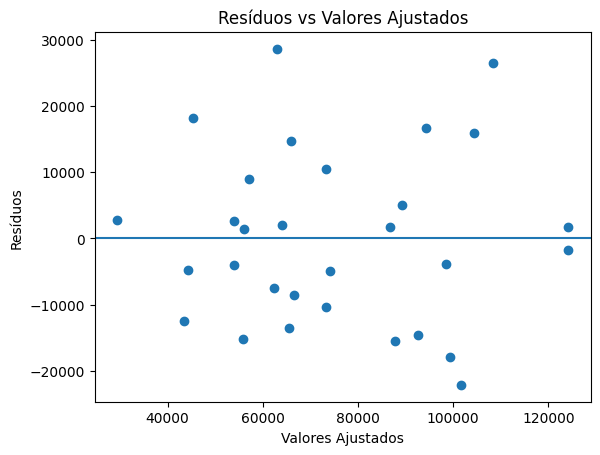

In [21]:
import matplotlib.pyplot as plt

residuos = model.resid
valores_ajustados = model.fittedvalues

plt.scatter(valores_ajustados, residuos)
plt.axhline(y=0)
plt.xlabel("Valores Ajustados")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Valores Ajustados")
plt.show()

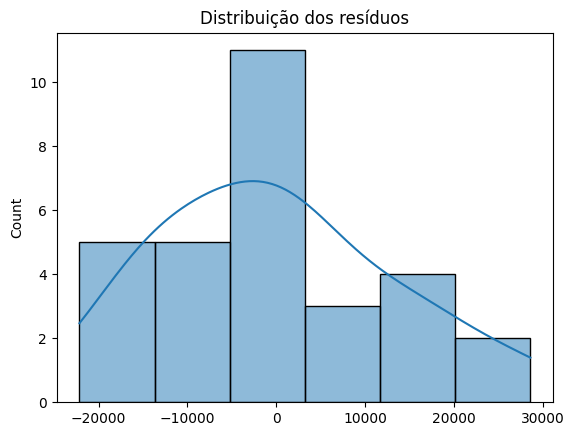

In [22]:
import seaborn as sns

sns.histplot(residuos, kde=True)
plt.title("Distribuição dos resíduos")
plt.show()

In [23]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuos, X_const)

labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

{'Lagrange multiplier statistic': np.float64(3.2159996049034865), 'p-value': np.float64(0.3595060828857522), 'f-value': np.float64(1.0406211232334388), 'f p-value': np.float64(0.3910890513723111)}


In [24]:
bp_df = pd.DataFrame({
    'Teste': ['Breusch-Pagan'] * 4,
    'Indicador': ['LM', 'p-valor (LM)', 'F', 'p-valor (F)'],
    'Valor': bp_test
})

print(bp_df)

           Teste     Indicador     Valor
0  Breusch-Pagan            LM  3.216000
1  Breusch-Pagan  p-valor (LM)  0.359506
2  Breusch-Pagan             F  1.040621
3  Breusch-Pagan   p-valor (F)  0.391089


In [25]:
import pandas as pd
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuos, X_const)

labels = ['Estatística LM', 'p-valor LM', 'Estatística F', 'p-valor F']

bp_df = pd.DataFrame({
    'Métrica': labels,
    'Valor': bp_test
})

print(bp_df)

          Métrica     Valor
0  Estatística LM  3.216000
1      p-valor LM  0.359506
2   Estatística F  1.040621
3       p-valor F  0.391089


# =========================================
# 3. AVALIAÇÃO DE CANAIS
# =========================================

In [26]:
# Previsão
X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test_sm)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n===== AVALIAÇÃO =====")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

# Impacto por canal (coeficientes)
coef = model.params

print("\n===== IMPACTO POR CANAL =====")
print(coef)


===== AVALIAÇÃO =====
RMSE: 18050.100994362478
MAE: 13584.837165820905

===== IMPACTO POR CANAL =====
const           -4629.796588
invest_google       2.773204
invest_meta         6.363444
invest_tiktok      -1.199072
dtype: float64


# =========================================
# 4. SIMULAÇÃO DE CENÁRIOS
# =========================================

In [27]:
# Cenário: +20% Google
cenario = test.copy()
cenario['invest_google'] *= 1.2

X_cenario = sm.add_constant(cenario[['invest_google','invest_meta','invest_tiktok']])
cenario['receita_prevista'] = model.predict(X_cenario)

print("\n===== SIMULAÇÃO =====")
print(cenario[['data','receita_prevista']].head())


===== SIMULAÇÃO =====
         data  receita_prevista
30 2025-11-01      50872.614647
31 2025-11-02      50826.748908
32 2025-11-03      26365.584380
33 2025-11-04      50958.429758
34 2025-11-05      81085.821513


In [28]:
cenario_meta = test.copy()
cenario_meta['invest_meta'] *= 1.2

X_meta = sm.add_constant(cenario_meta[['invest_google','invest_meta','invest_tiktok']])
cenario_meta['receita_prevista'] = model.predict(X_meta)

print(cenario_meta[['data','receita_prevista']].head())

         data  receita_prevista
30 2025-11-01      48434.637838
31 2025-11-02      53844.431507
32 2025-11-03      27898.911952
33 2025-11-04      54460.773403
34 2025-11-05      82760.120166


In [29]:
cenario_meta[['data','receita_prevista']]

,data,receita_prevista
30,2025-11-01,48434.637838
31,2025-11-02,53844.431507
32,2025-11-03,27898.911952
33,2025-11-04,54460.773403
34,2025-11-05,82760.120166
35,2025-11-06,68999.942015
36,2025-11-07,79941.888862
37,2025-11-08,37271.194897
38,2025-11-09,101300.716042
39,2025-11-10,54831.852934


# =========================================
# 5. RECOMENDAÇÃO DE BUDGET
# =========================================

In [30]:
print("\n===== RECOMENDAÇÃO DE BUDGET =====")

impacto_google = coef['invest_google']
impacto_meta = coef['invest_meta']
impacto_tiktok = coef['invest_tiktok']

print(f"Google: {impacto_google}")
print(f"Meta: {impacto_meta}")
print(f"TikTok: {impacto_tiktok}")

# Sugestão automática
melhor_canal = max(
    {'Google': impacto_google, 'Meta': impacto_meta, 'TikTok': impacto_tiktok},
    key=lambda x: {'Google': impacto_google, 'Meta': impacto_meta, 'TikTok': impacto_tiktok}[x]
)

print(f"\nCanal com maior impacto marginal: {melhor_canal}")


===== RECOMENDAÇÃO DE BUDGET =====
Google: 2.773204468879654
Meta: 6.363443565601476
TikTok: -1.199071733329096

Canal com maior impacto marginal: Meta


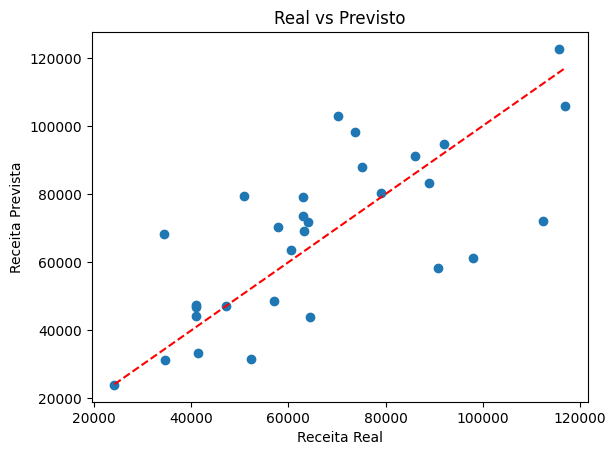

In [31]:
plt.figure()

# pontos
plt.scatter(y_test, y_pred, label='Valores previstos')

# linha ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red',
         linestyle='--',
         label='Linha ideal')

plt.xlabel("Receita Real")
plt.ylabel("Receita Prevista")
plt.title("Real vs Previsto")


plt.show()